<a href="https://colab.research.google.com/github/GabyPaolaING/Machine-Learning/blob/main/Multi_layer_Perceptron_for_banking%2C_product_subscription_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Red Neuronal MLP con Scikit-Learn

##1. Descripción de la librería Scikit-Learn para MLP


1.1 Clases y funciones empleadas

Scikit-Learn es una librería de Python que permite implementar algoritmos de Machine Learning de forma sencilla.

Para construir una Red Neuronal tipo MLP (Multi-Layer Perceptron) utilizaremos las siguientes clases y funciones:

*  MLPClassifier: Implementa la red neuronal para problemas de clasificación

*  train_test_split: Divide el dataset en entrenamiento y prueba

*  StandardScaler: Estandariza los datos

*  classification_report, confusion_matrix, accuracy_score: Permiten evaluar el modelo

In [23]:
# Librerías para manejo de datos
import numpy as np
import pandas as pd

# Modelo de red neuronal
from sklearn.neural_network import MLPClassifier

# División de datos
from sklearn.model_selection import train_test_split

# Estandarización
from sklearn.preprocessing import StandardScaler

# Métricas de evaluación
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

1.2 Parámetros:

Explicación:

*  hidden_layer_sizes: define la cantidad de capas ocultas y neuronas

*  activation: función de activación (relu es la más usada)

*  solver: algoritmo de optimización (adam es eficiente)

*  max_iter: número de iteraciones de entrenamiento

*  random_state: asegura reproducibilidad

In [24]:
MLPClassifier(
    hidden_layer_sizes=(10,10),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=1
)

MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=500, random_state=1)

##2. Pipeline

2.1 Descripción del problema

El objetivo es predecir si un cliente contratará un depósito a plazo en un banco.

Este problema es de tipo clasificación binaria, donde:

*  1 → el cliente acepta el servicio

*  0 → el cliente no acepta

La variable objetivo es y.

##2.2 Exploración y preprocesamiento del dataset

2.2.1 Describir las variables: tipos e interpretación

El dataset contiene:

*  Variables numéricas:

   *  age, balance, duration, campaign, pdays, previous

*  Variables categóricas:

    *  job, marital, education, housing, loan, etc.

*  Variable objetivo:

    *  y (respuesta del cliente)

In [25]:
# Cargar dataset
df = pd.read_csv('/content/sample_data/bank-full.csv', sep=';')

# Ver estructura
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


2.2.2 Variables independientes y dependiente

*  y es lo que queremos predecir

*  X contiene la información del cliente

In [26]:
# Variable dependiente (salida)
y = df['y']

# Variables independientes (entrada)
X = df.drop('y', axis=1)

2.2.3 Variables que se eliminan del Dataset y ¿por qué?

La variable duration puede generar sesgo porque contiene información posterior al contacto con el cliente, lo cual puede hacer que el modelo tenga ventaja injusta.

In [27]:
# Eliminación opcional
# X = X.drop('duration', axis=1)

2.2.4 Estandarización del dataset: ¿por qué y cómo?

¿Por qué estandarizar?

Las redes neuronales funcionan mejor cuando los datos están en la misma escala, ya que:

*  Mejora la velocidad de aprendizaje

*  Evita que variables grandes dominen el modelo

In [28]:
# Codificar variables categóricas
X = pd.get_dummies(X, drop_first=True)

# Convertir variable objetivo a binaria
y = y.map({'yes': 1, 'no': 0})

# Estandarizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

a estandarización transforma valores como:

*  Edad: 50 → 0.3

*  Balance: 2000 → 0.5

Esto permite que todas las variables tengan la misma importancia.

In [29]:
#División del dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## 2.3 Model Selection

In [30]:
mlp = MLPClassifier(
    hidden_layer_sizes=(10, 10),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=1
)

Se define la arquitectura de la red neuronal:

*  2 capas ocultas con 10 neuronas

*  Función de activación ReLU

*  Optimizador Adam

##2.4 Model Training

Durante el entrenamiento:

*  El modelo realiza predicciones

*  Calcula el error

*  Ajusta los pesos mediante backpropagation

In [31]:
# Entrenamiento del modelo
mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=500, random_state=1)

##2.5 Model Prediction

In [33]:
def predecir_cliente(modelo, scaler, datos):
    # Estandarizar nuevos datos
    datos = scaler.transform([datos])

    # Realizar predicción
    pred = modelo.predict(datos)

    return pred[0]

##2.6 Model Evaluation

*  Accuracy: porcentaje de aciertos

*  Matriz de confusión: muestra errores y aciertos

*  Classification report: incluye precisión, recall y F1-score

In [34]:
y_pred = mlp.predict(X_test)

# Exactitud
print("Accuracy:", accuracy_score(y_test, y_pred))

# Matriz de confusión
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))

# Reporte de clasificación
print("Reporte:\n", classification_report(y_test, y_pred))

Accuracy: 0.9042353201371226
Matriz de confusión:
 [[7598  354]
 [ 512  579]]
Reporte:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95      7952
           1       0.62      0.53      0.57      1091

    accuracy                           0.90      9043
   macro avg       0.78      0.74      0.76      9043
weighted avg       0.90      0.90      0.90      9043



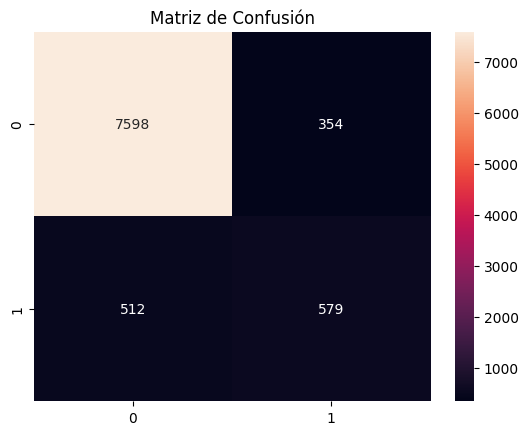

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Matriz de Confusión")
plt.show()